# New complex rules across stages


## Imports


In [1]:
import os
import sys
import warnings

from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
sys.path[:0] = [os.path.abspath(".."), os.path.abspath("../..")]

import data_helper as dh
import vis_helper as vh
import complex_stages_helper as stage
import complex_stages_vis as vis


## Parameters


In [2]:
RULE_MAX_ITEMS = 3
KINDS = ["attracts", "avoids"]
MAX_FDR = 0.05
STRENGTH_METRIC = "Lift"

# The stage column is chosen per run, not per notebook:
#   SCORE_COLUMN="Pathological score" jupyter nbconvert --execute ...
SCORE_COLUMN = os.environ.get("SCORE_COLUMN", "Clinical score")
SCORE_TAG = "path" if SCORE_COLUMN.startswith("Patho") else "clin"
STAGES = ["Control", "Mild", "Severe"]
ORGANS = ["Colon", "Duodenum"]

USE_CELL_ELIGIBILITY = True
MIN_CELLS_PER_TYPE = 20
MIN_RULE_FOVS = 5
TOP_RULES = 12
DETAIL_RULES = 2
NEW_MIN_STRENGTH = 1.3

SCOPE = "new"    # tags every figure this notebook saves


## Data loading


In [3]:
df_cells, df_fovs, df_biopsy = dh.load_spatial_data()
df_results = dh.load_results(
    rule_max_items=RULE_MAX_ITEMS,
    kind=None,
    max_fdr=1.0,
    informative_only=False,
)
all_rules = stage.prepare_rules(df_results, df_fovs)


Dropped 21 FOVs: Control_S


Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


Read results_CN_pairwise.csv + results_CN_complex.csv
Loaded 1190114 rules.


Kept 1190114 rules at FDR <= 1.0.


Kept 1172931 rules naming no Unidentified.


Kept 213816 rules (max_items=3, kind=None).


## Short analysis functions


In [4]:
def slug(text):
    """A short file-safe name for a rule."""
    text = str(text).lower().replace(" -> ", "_").replace(",", "").replace(" ", "_")
    return "".join(ch for ch in text if ch.isalnum() or ch == "_")[:60]


def figure_name(scope, kind, organ, panel, name=None):
    """One naming rule for every figure this notebook saves."""
    parts = [scope, SCORE_TAG, kind, organ.lower(), panel]
    if name is not None:
        parts.append(slug(name))
    return "_".join(parts) + ".png"


def strength_label(kind):
    return STRENGTH_METRIC


def scope_label(kind):
    denominator = (
        f"{MIN_CELLS_PER_TYPE}+ cells per rule cell type"
        if USE_CELL_ELIGIBILITY else "all FOVs"
    )
    return " · ".join([
        kind,
        f"new complex rules · strength >= {NEW_MIN_STRENGTH}",
        f"stage column: {SCORE_COLUMN}",
        f"FDR <= {MAX_FDR}",
        denominator,
        f"at least {MIN_RULE_FOVS} rule FOVs in one stage",
    ])


## Results


In [5]:
def show_kind(kind):
    display(Markdown(f"## {kind.title()}"))
    kind_rules = all_rules[all_rules["Kind"] == kind].copy()
    complex_rules = stage.select_complex_rules(
        kind_rules,
        max_fdr=MAX_FDR,
        new_only=True,
        min_strength=NEW_MIN_STRENGTH,
        metric=STRENGTH_METRIC,
    )
    eligibility = stage.rule_eligibility(
        complex_rules, df_cells, MIN_CELLS_PER_TYPE
    )

    for organ in ORGANS:
        display(Markdown(f"### {organ}"))
        prevalence = stage.stage_prevalence(
            complex_rules,
            kind_rules,
            eligibility,
            df_fovs,
            organ,
            STAGES,
            SCORE_COLUMN,
            MAX_FDR,
            USE_CELL_ELIGIBILITY,
        )
        top, ranked_names = stage.rank_rules(
            prevalence, STAGES, MIN_RULE_FOVS, TOP_RULES
        )
        display(stage.result_table(top, new_only=True))
        vis.plot_prevalence_overview(
            top,
            STAGES,
            organ=organ,
            params=scope_label(kind),
            save=figure_name(SCOPE, kind, organ, "overview"),
        )

        chosen = list(ranked_names[:DETAIL_RULES])
        for name in chosen:
            rule_prevalence = top[top["name"].astype(str) == name].copy()
            availability = stage.availability_breakdown(
                [name], complex_rules, kind_rules, eligibility, df_fovs,
                organ, STAGES, SCORE_COLUMN, MAX_FDR,
            )
            vis.plot_availability_breakdown(
                availability, STAGES, [name], organ=organ,
                params=scope_label(kind),
                save=figure_name(SCOPE, kind, organ, "avail", name),
            )
            strengths = stage.patient_strengths(
                name,
                complex_rules,
                kind_rules,
                eligibility,
                df_fovs,
                organ,
                STAGES,
                SCORE_COLUMN,
                STRENGTH_METRIC,
                USE_CELL_ELIGIBILITY,
            )
            abundance = stage.cell_abundance(
                name,
                complex_rules,
                df_cells,
                eligibility,
                df_fovs,
                organ,
                STAGES,
                SCORE_COLUMN,
                USE_CELL_ELIGIBILITY,
            )
            vis.plot_prevalence_and_strength(
                rule_prevalence,
                strengths,
                STAGES,
                metric=strength_label(kind),
                organ=organ,
                params=scope_label(kind),
                new_only=True,
                abundance=abundance,
                save=figure_name(SCOPE, kind, organ, "rule", name),
            )
            examples = stage.fov_examples(
                name,
                complex_rules,
                kind_rules,
                eligibility,
                df_fovs,
                organ,
                STAGES,
                SCORE_COLUMN,
                STRENGTH_METRIC,
                USE_CELL_ELIGIBILITY,
                new_only=True,
            )
            vh.plot_stage_rule_fovs(
                examples,
                STAGES,
                df_cells,
                df_fovs,
                organ=organ,
                subtitle="New complex rule",
                params=scope_label(kind),
                cell_size=11,
                save=figure_name(SCOPE, kind, organ, "fovs", name),
            )


## Attractions


## Attracts

### Colon

,name,stage,complex prevalence
1185,"Fibroblast, Muscle -> Neuron",Control,1 / 14 (7%)
1186,"Fibroblast, Muscle -> Neuron",Mild,5 / 15 (33%)
1187,"Fibroblast, Muscle -> Neuron",Severe,2 / 12 (17%)
60,"Epithelial, Macrophage -> Plasma",Control,6 / 25 (24%)
61,"Epithelial, Macrophage -> Plasma",Mild,1 / 12 (8%)
62,"Epithelial, Macrophage -> Plasma",Severe,0 / 18 (0%)
165,"Fibroblast, Goblet -> Plasma",Control,6 / 25 (24%)
166,"Fibroblast, Goblet -> Plasma",Mild,1 / 12 (8%)
167,"Fibroblast, Goblet -> Plasma",Severe,0 / 14 (0%)
15,"Epithelial, SMV -> Plasma",Control,5 / 21 (24%)


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_attracts_colon_overview.png


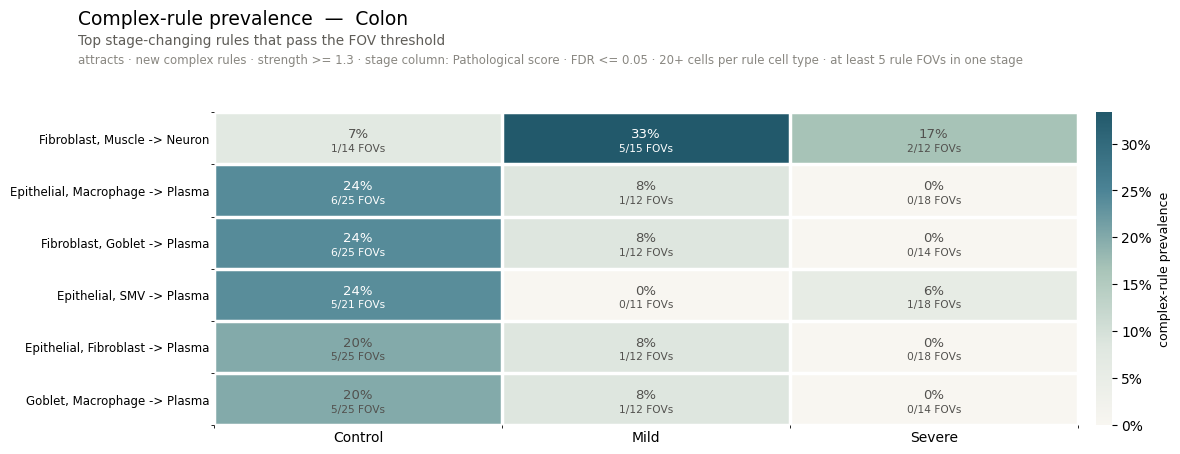

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_attracts_colon_avail_fibroblast_muscle_neuron.png


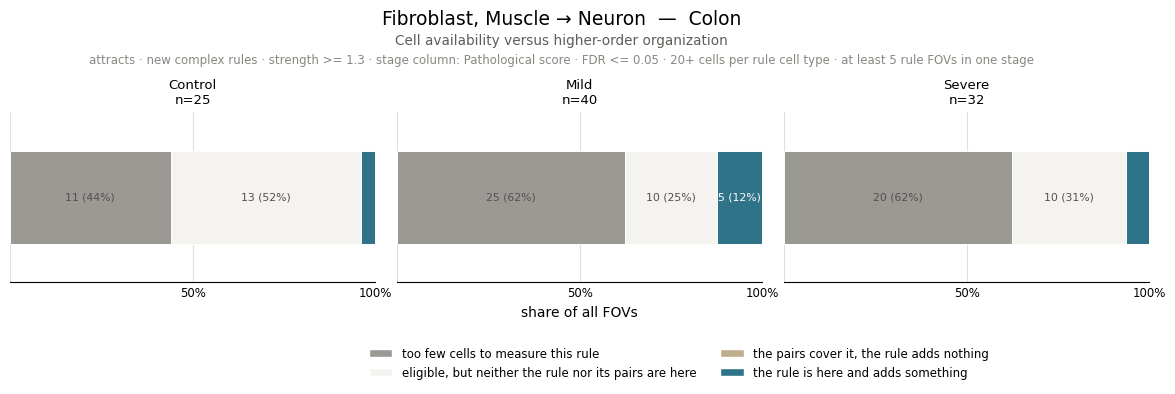

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_attracts_colon_rule_fibroblast_muscle_neuron.png


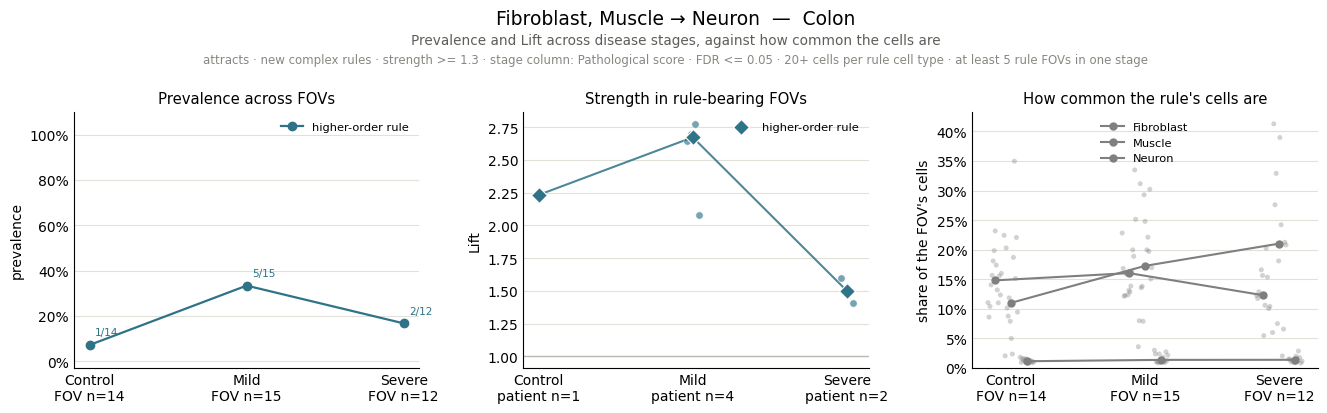

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_attracts_colon_fovs_fibroblast_muscle_neuron.png


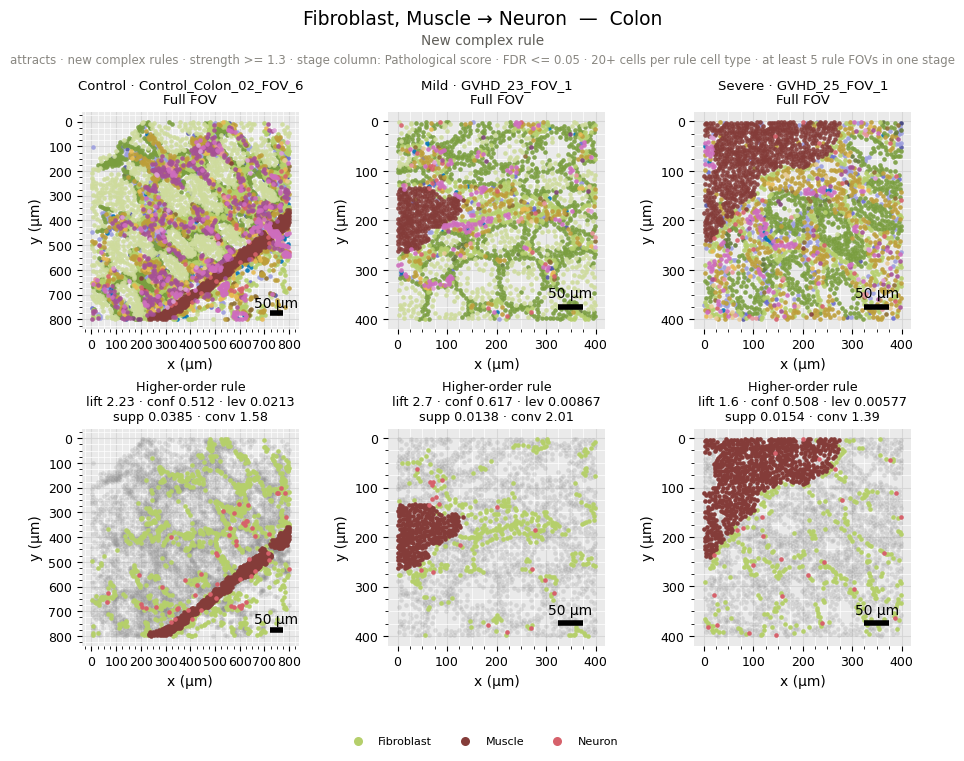

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_attracts_colon_avail_epithelial_macrophage_plasma.png


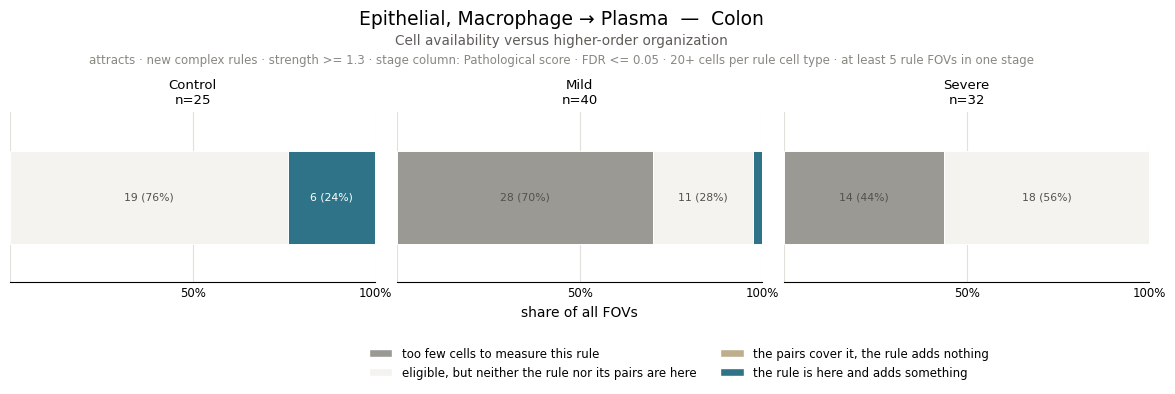

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_attracts_colon_rule_epithelial_macrophage_plasma.png


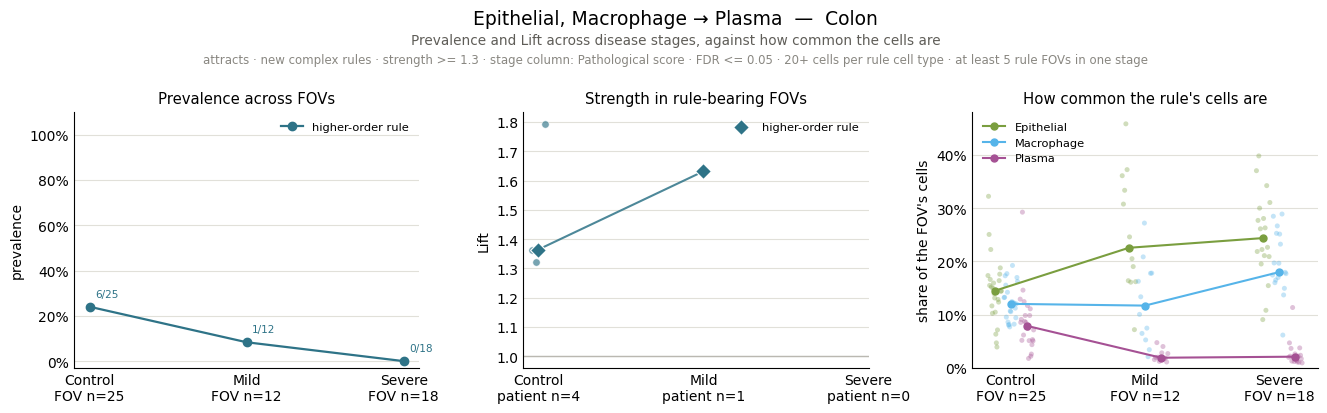

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_attracts_colon_fovs_epithelial_macrophage_plasma.png


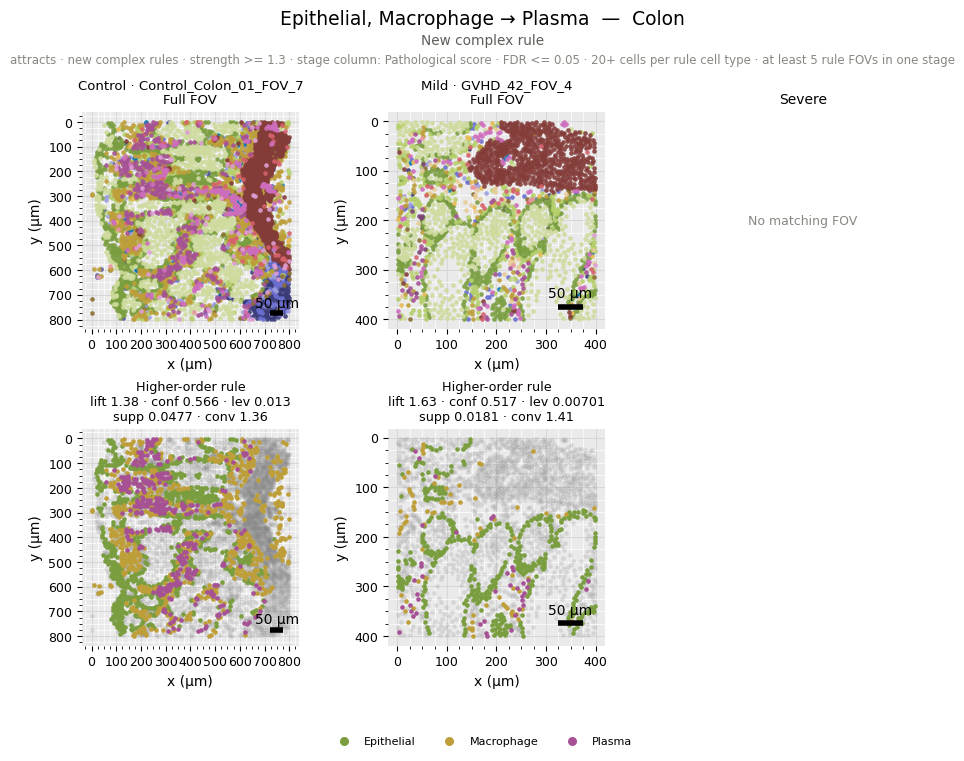

### Duodenum

,name,stage,complex prevalence
63,"Epithelial, Neuron -> Paneth",Control,3 / 11 (27%)
64,"Epithelial, Neuron -> Paneth",Mild,8 / 58 (14%)
65,"Epithelial, Neuron -> Paneth",Severe,0 / 6 (0%)
303,"Mesenchymal_VIM, SMV -> Endothelial",Control,0 / 1 (0%)
304,"Mesenchymal_VIM, SMV -> Endothelial",Mild,5 / 30 (17%)
305,"Mesenchymal_VIM, SMV -> Endothelial",Severe,0 / 18 (0%)
888,"Epithelial, SMV -> Plasma_CD38",Control,0 / 26 (0%)
889,"Epithelial, SMV -> Plasma_CD38",Mild,7 / 70 (10%)
890,"Epithelial, SMV -> Plasma_CD38",Severe,3 / 22 (14%)
1041,"Epithelial, Fibroblast -> Plasma",Control,0 / 30 (0%)


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_attracts_duodenum_overview.png


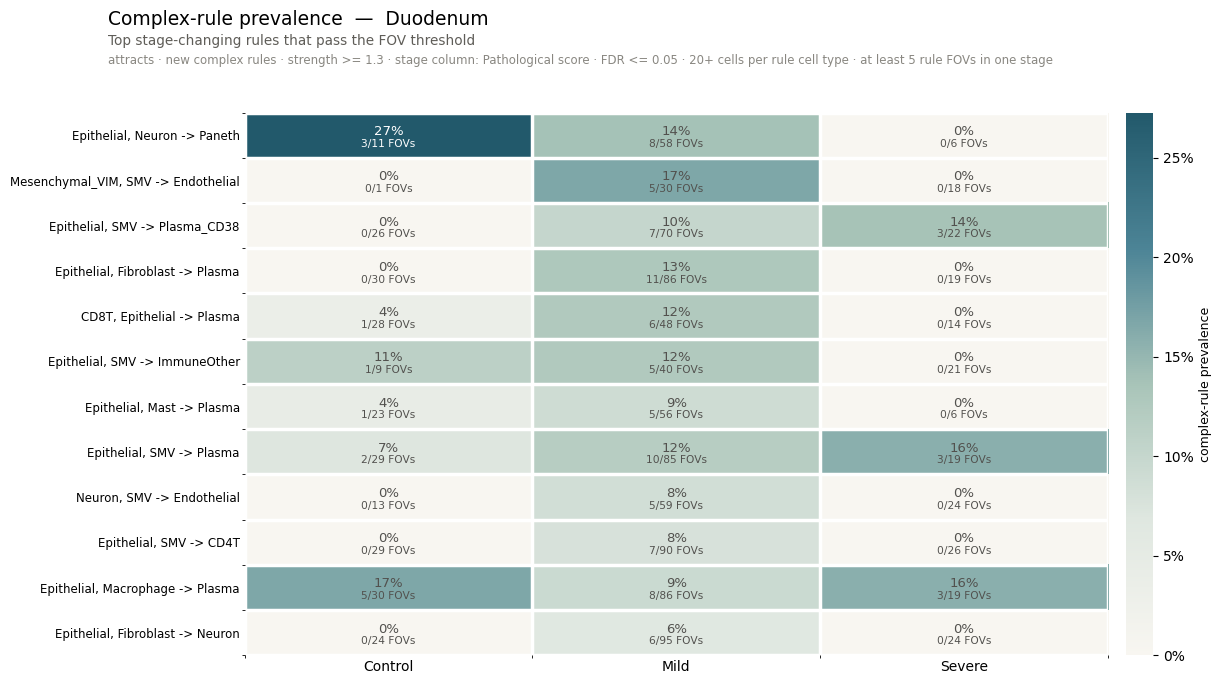

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_attracts_duodenum_avail_epithelial_neuron_paneth.png


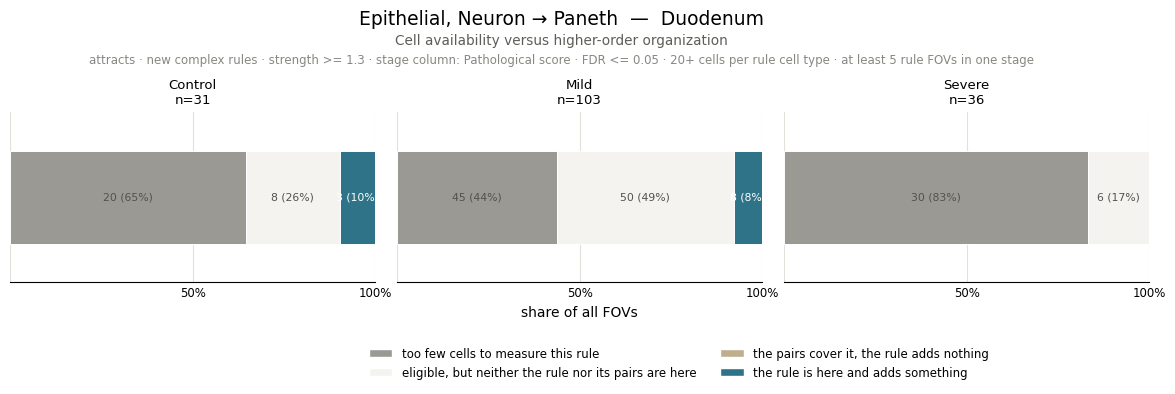

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_attracts_duodenum_rule_epithelial_neuron_paneth.png


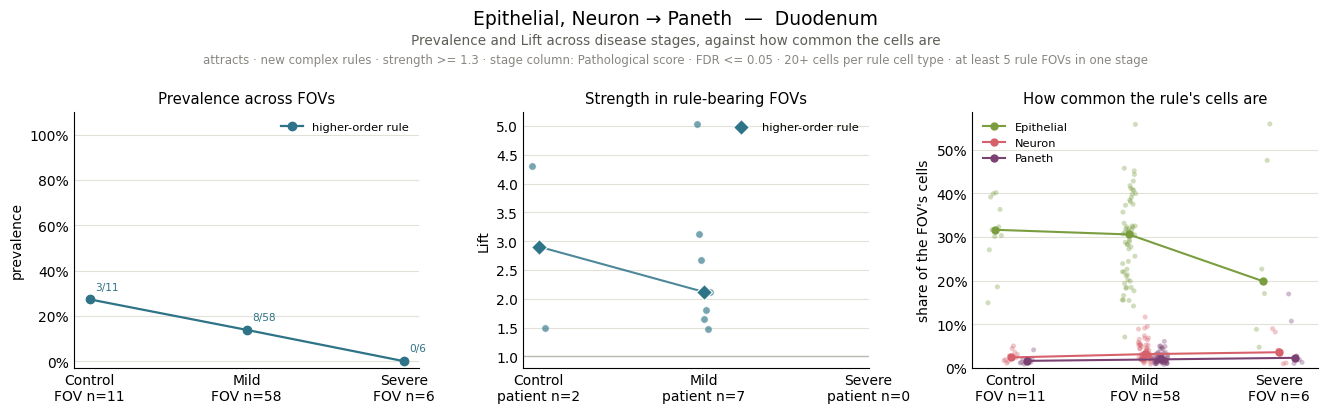

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_attracts_duodenum_fovs_epithelial_neuron_paneth.png


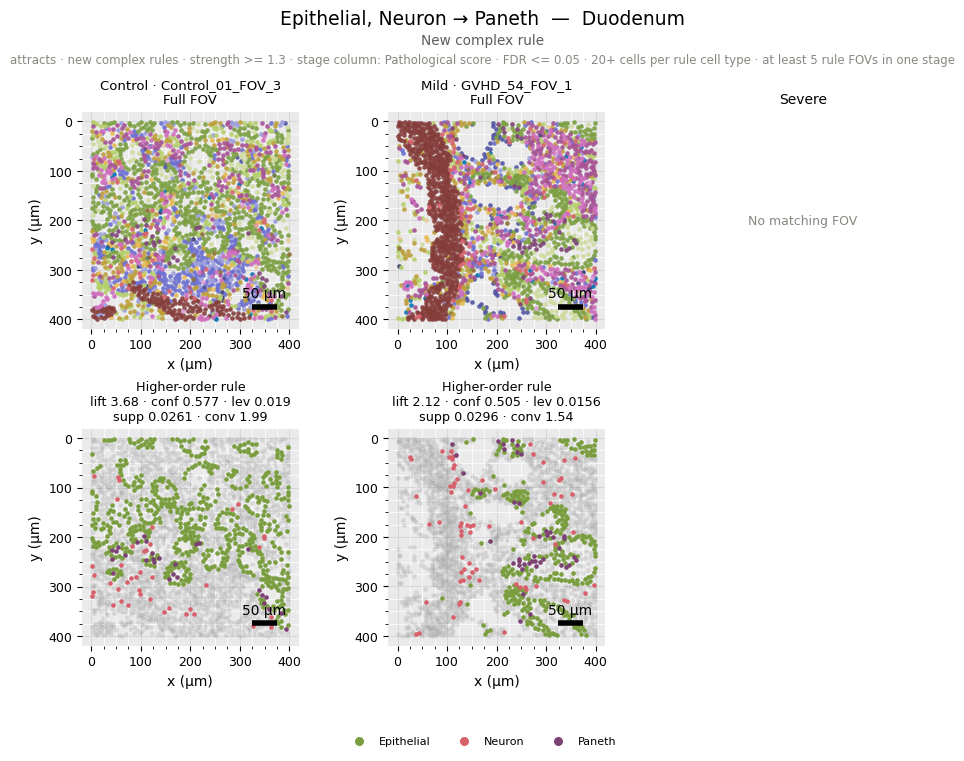

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_attracts_duodenum_avail_mesenchymal_vim_smv_endothelial.png


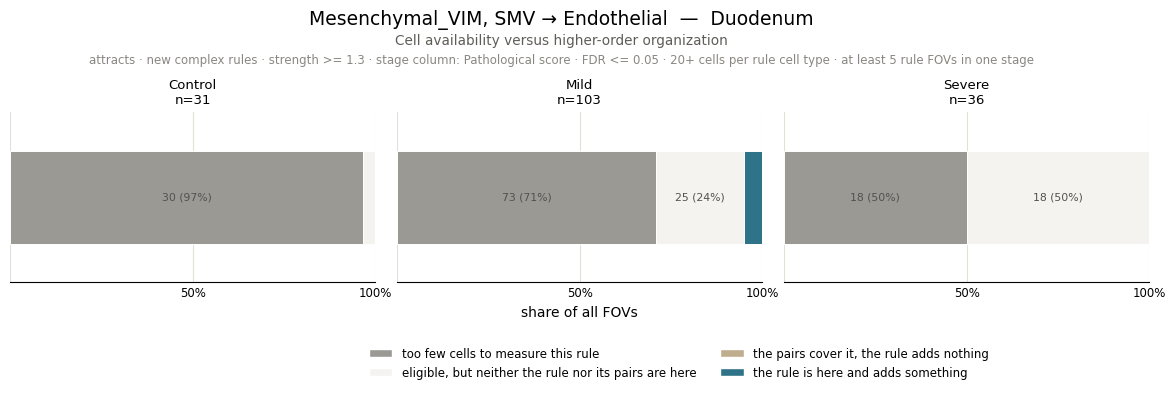

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_attracts_duodenum_rule_mesenchymal_vim_smv_endothelial.png


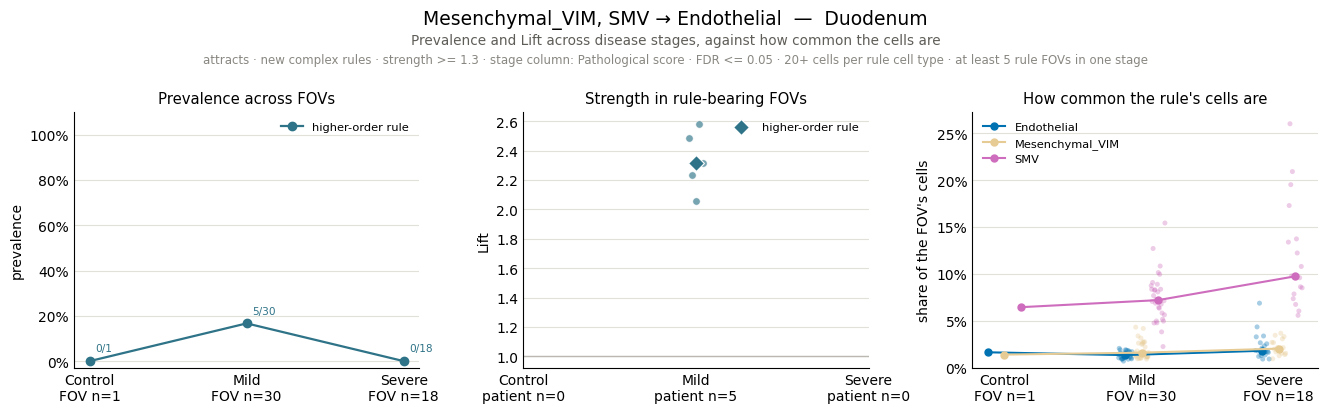

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_attracts_duodenum_fovs_mesenchymal_vim_smv_endothelial.png


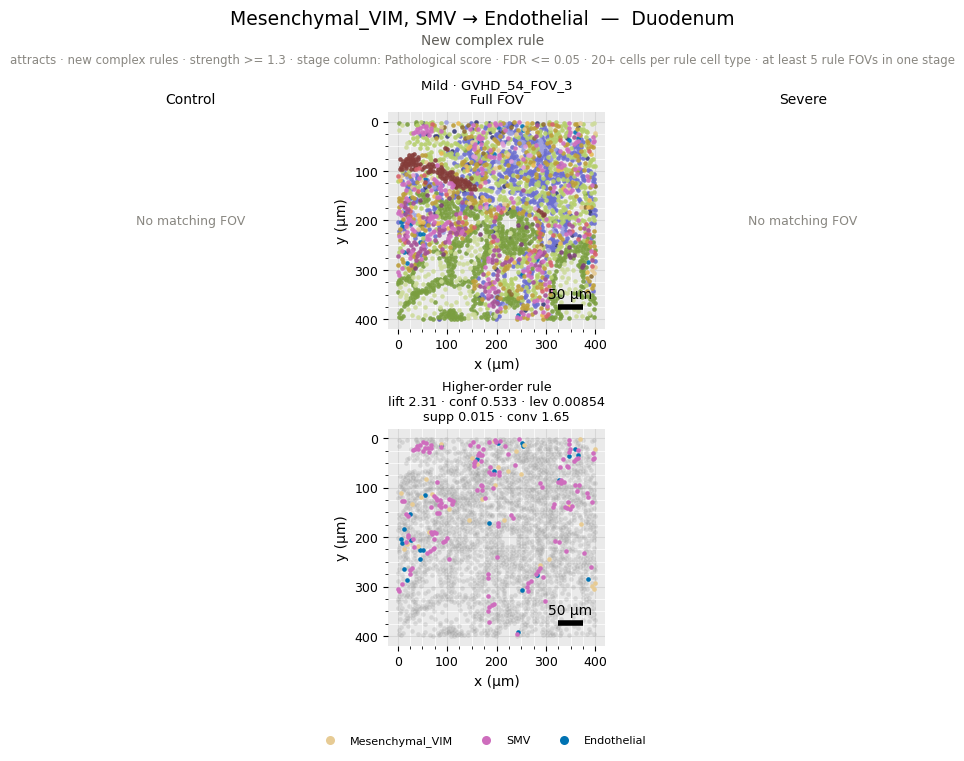

In [6]:
show_kind("attracts")


## Avoidances (negative spatial rules)


## Avoids

### Colon

,name,stage,n_fovs,complex,simpler,complex_share,simpler_share


No rules pass the FOV threshold.


### Duodenum

,name,stage,complex prevalence
1398,"Muscle -> Macrophage, SMV",Control,0 / 17 (0%)
1399,"Muscle -> Macrophage, SMV",Mild,7 / 65 (11%)
1400,"Muscle -> Macrophage, SMV",Severe,1 / 27 (4%)
789,"Muscle, SMV -> Fibroblast",Control,0 / 17 (0%)
790,"Muscle, SMV -> Fibroblast",Mild,6 / 65 (9%)
791,"Muscle, SMV -> Fibroblast",Severe,1 / 27 (4%)
282,"Muscle -> Fibroblast, SMV",Control,1 / 17 (6%)
283,"Muscle -> Fibroblast, SMV",Mild,5 / 65 (8%)
284,"Muscle -> Fibroblast, SMV",Severe,0 / 27 (0%)
108,"Muscle, SMV -> Macrophage",Control,1 / 17 (6%)


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_avoids_duodenum_overview.png


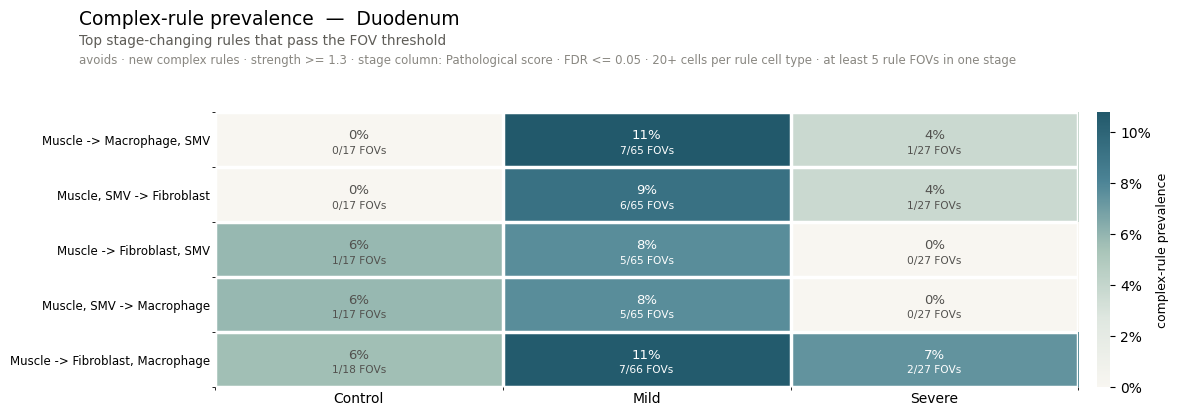

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_avoids_duodenum_avail_muscle_macrophage_smv.png


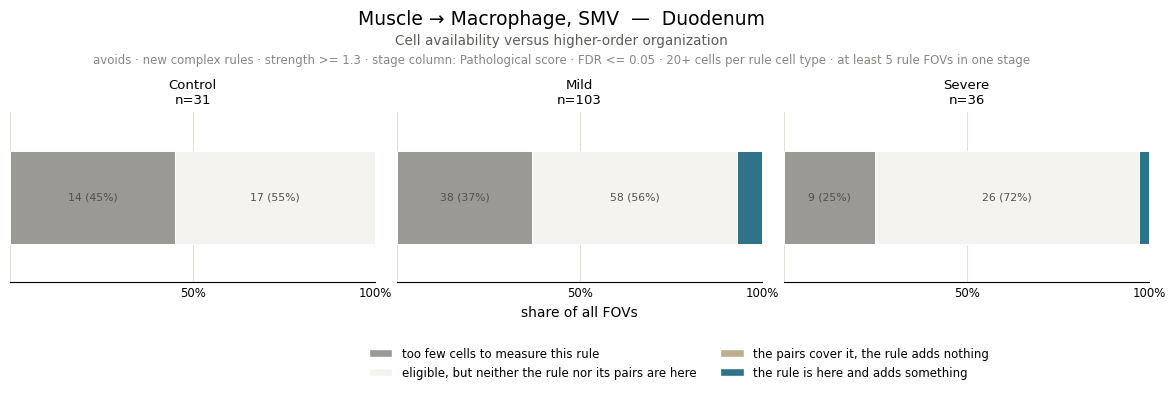

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_avoids_duodenum_rule_muscle_macrophage_smv.png


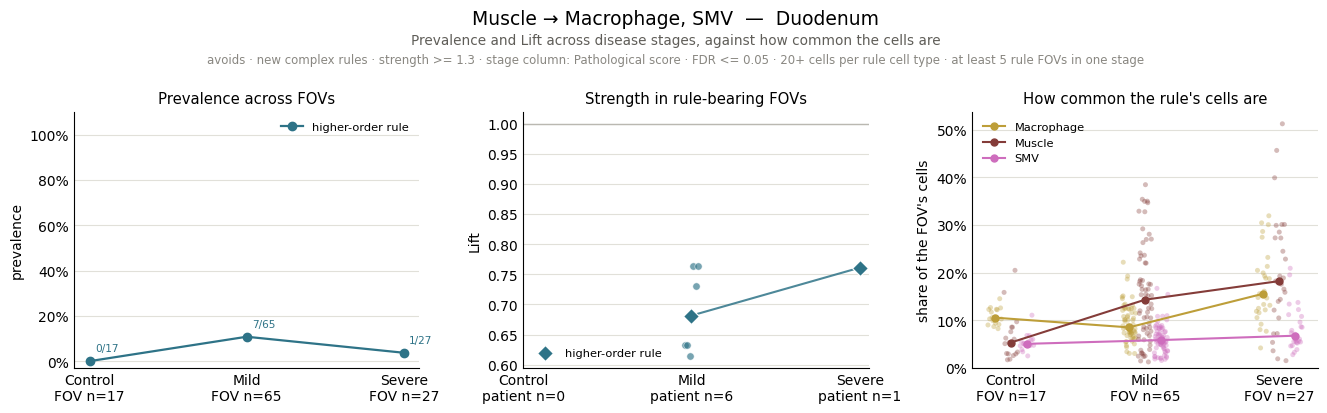

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_avoids_duodenum_fovs_muscle_macrophage_smv.png


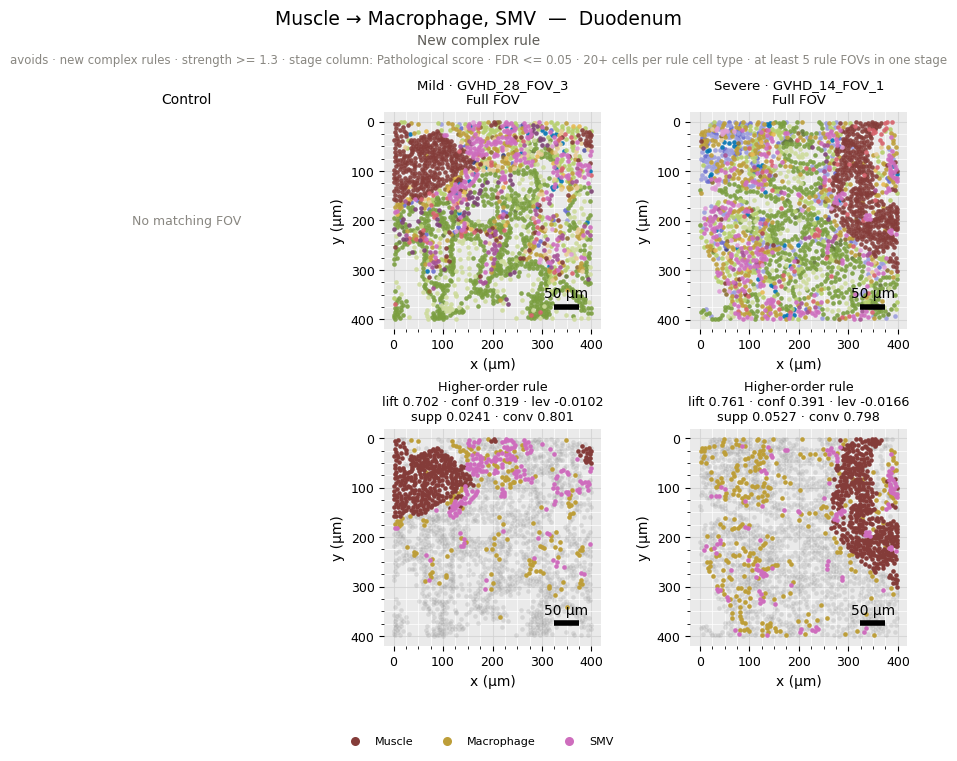

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_avoids_duodenum_avail_muscle_smv_fibroblast.png


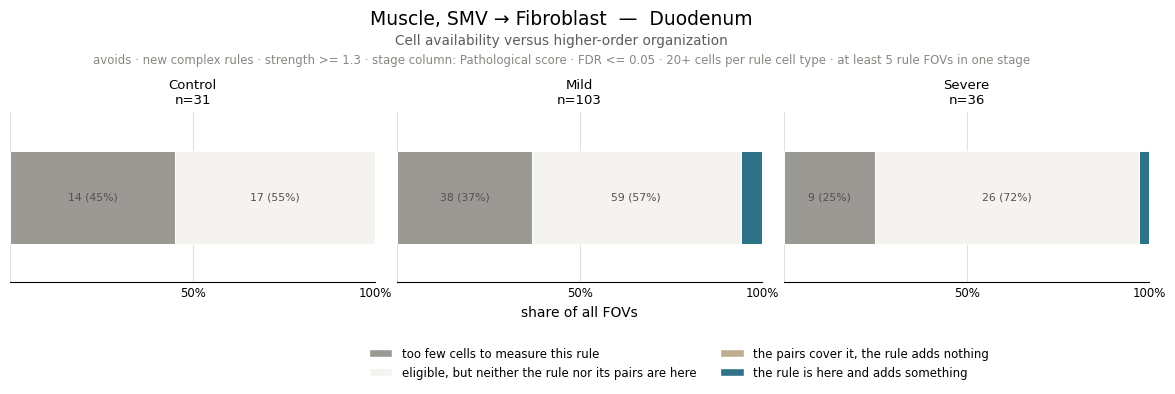

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_avoids_duodenum_rule_muscle_smv_fibroblast.png


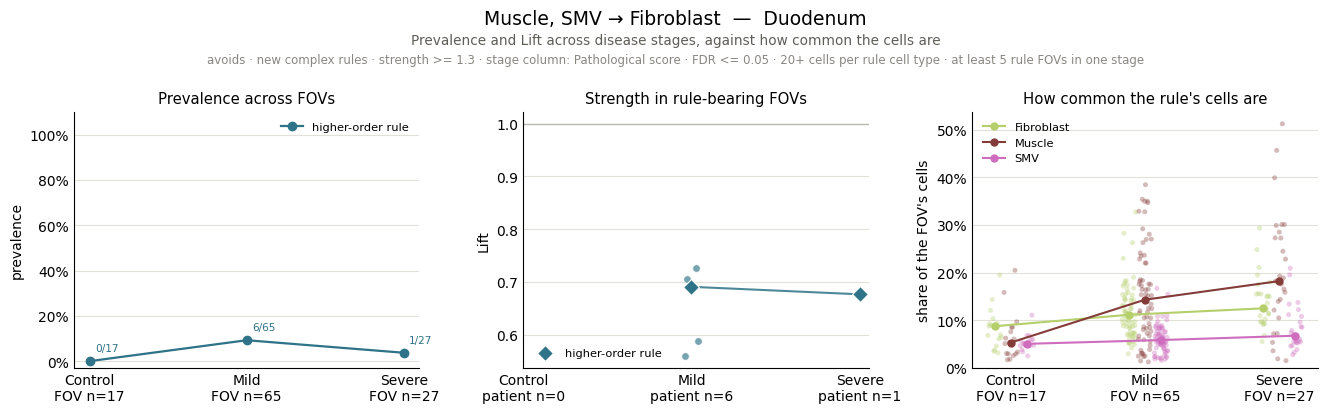

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\new_path_avoids_duodenum_fovs_muscle_smv_fibroblast.png


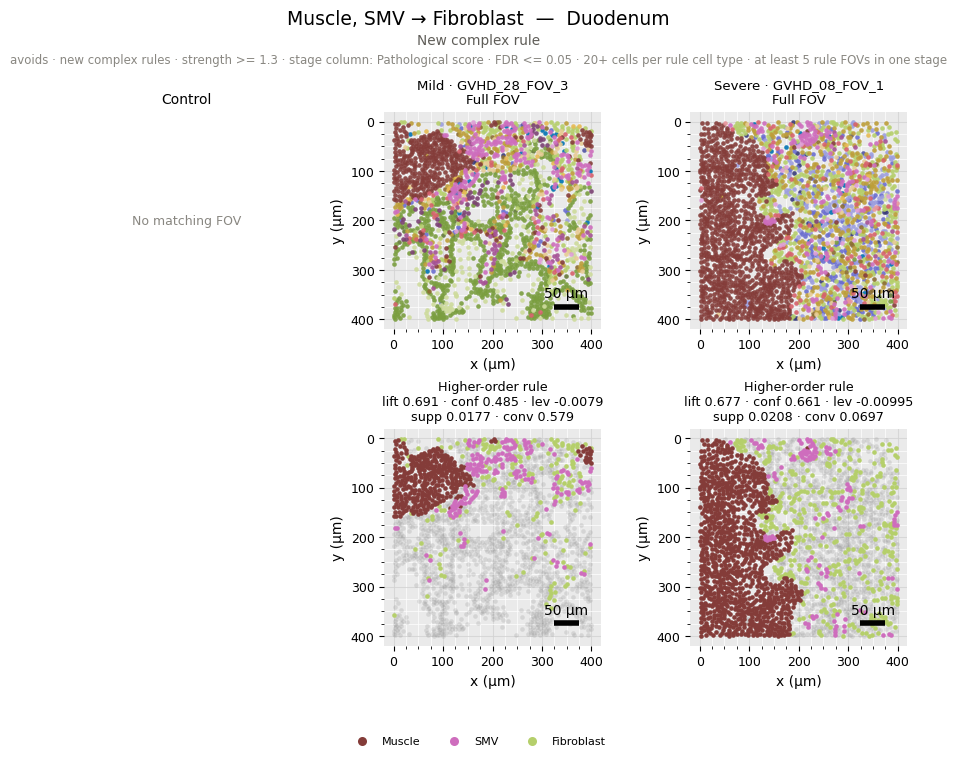

In [7]:
show_kind("avoids")
